# **ENGG680 - Introduction to Digital Engineering**
## *Lab Assignment 2: Introduction to Non-linear Square and Machine Learning*

## Preliminary: Certificate of Work (5 marks)


*We, the undersigned, certify that this is our own work, which has been done expressly for this course, either without the assistance of any other party or where appropriate we have acknowledged the work of others. Further, we have read and understood the section in the university calendar on plagiarism/cheating/other academic misconduct and we are aware of the implications thereof. We request that the total mark for this assignment be distributed as follows among group members:*

|          | First Name | Last Name | Signature (Full Name, Date) | Hours | Contribution % |
|----------|------------|-----------|-----------------------------|-------|----------------|
| Member 1: | First Name | Last Name | Signature                   | Hours | Contribution |
| Member 2: | Sepehr | Akhiani | Sepehr Akhiani              | 10 Hours | 25% |
| Member 3: | First Name | Last Name | GDKHSD                      | Hours | Contribution |
| Member 4: | First Name | Last Name | Signature                   | Hours | Contribution |


# **PART 1: Non-linear Estimation - LSE & Gradiant Decent (35 Marks)**

The following materials will be our states of interest, and we are going to estimate them using **Least Square method** and **Gradient Descent method**

## **SinglePointPositioning Formulas**

### **Observations:** Pseudorange [m]

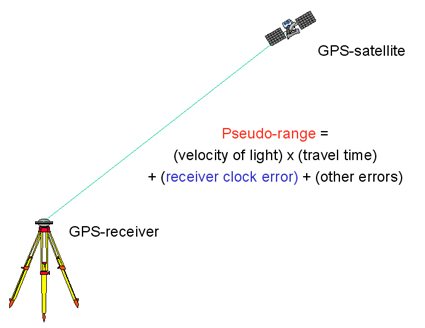

<font size="1.5">Image source: *ICA Course on Toponymy. https://unstats.un.org/unsd/geoinfo/ungegn/docs/_data_icacourses/_HtmlModules/_Selfstudy/S06/S06_05b.html.*</font>

**Pseudorange** is the *pseudo* distance between a satellite and a satellite signal receiver on the ground. In simple words, it contains the geometric range between the satellite and the receiver, with additional associated errors.

The simplified version of the Pseudorange measurement model is:
$$P=\rho-cdT+ϵ_{sum}$$ and
$$\rho=\sqrt{(x_s - x_r)^2 + (y_s - y_r)^2 + (z_s - z_r)^2}$$
where
$$\rho=geometric\ range$$
$${x_s, y_s, z_s, x_r,y_r,z_r} = 3D\ coordinates\ of\ satellite\ and\ receiver$$
$$cdT = receiver\ clock\ offset$$
$$ϵ_{sum}=general\ errors\ term\ (ϵ_{sum}=\Delta \rho + \Delta_{\text{ion}} + \Delta_{\text{trop}} + \epsilon_P + cdt)$$

\
Note: the 3D **positions of satellites** are given in this assignment.

### **Unknown States:** Position of receiver & receiver clock offset

We use the psuedorange measurements to estimate the receiver's **3-dimensional position** and the **receiver clock offset:** $$X={x_r,y_r,z_r,cdT}$$.


## **Setup & Intialization for LSE and Gradient Decent (5 Marks)**

In [53]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [54]:
# Load the psuedorange measurements and satellites' positions files, store them in the format of numpy array
# Add small random perturbations in the range (0, 0.5) to pseudorange measurements to simulate measurement noise
# (hint: use pandas library to parse excel files into dataframe first, then convert them to numpy arrays)
# (1 marks)
df_pseudorange = pd.read_excel('pseudoranges.xlsx')
df_sat_pos = pd.read_excel('satellite_position.xlsx')

pseudorange = df_pseudorange.iloc[:, 1].to_numpy(dtype=float)
sat_pos = df_sat_pos.iloc[:, 1:4].to_numpy(dtype=float)

np.random.seed(42)  # For reproducible results
pseudorange = pseudorange + np.random.uniform(0, 0.5, size=pseudorange.shape)
print("Pseudorange measurements with noise:\n", pseudorange)
print("\nSatellite positions (ECEF):\n", sat_pos)

Pseudorange measurements with noise:
 [22919741.14869956 20459894.56315595 22400338.77941037 22829141.21192965
 22342014.89518462 25646454.61429046 23814776.2744646  24311399.75024017
 21353640.44123681 24971609.99147099 20638981.06929275]

Satellite positions (ECEF):
 [[  5280791.73836563 -25501460.1192133    4649508.28809917]
 [ -2159656.05205653 -21116024.7920163   15597909.1971221 ]
 [ 10371852.1682927  -21713111.3497771   10558686.998121  ]
 [-16085760.7811889    4285071.21612309  20742042.1246963 ]
 [-14312988.0806279  -22045014.2659254    4671208.3988653 ]
 [ -2435718.18737303  16257205.12951     21099779.5379103 ]
 [ 15912467.1868696   -3462515.31492602  21053628.253335  ]
 [ 16271848.163885     -218766.32031082  21035332.7037679 ]
 [-19247035.5286677   -7259803.67892242  16472981.9071979 ]
 [-15931152.0364578   12077367.2515846   18058076.7648504 ]
 [ -7680014.10843999 -13855462.7231353   21842975.3728112 ]]


In [55]:
# define the number of measurements n and the number of unknown states m
# (2 mark)
n = len(pseudorange)
m = 4

print("Number of measurements (n):", n)
print("Number of unknown states (m):", m)

Number of measurements (n): 11
Number of unknown states (m): 4


In [56]:
# GroundTruth coordiantes of the receiver
GroundTruth=np.array([-1633489.37967725,	-3651627.18250363,	4952481.61954918])

In [57]:
# define a function called euclidean_norm, which computes the geometric distances between satellites and receiver
# the input of the function should be two arrays: receiver_pos and satellite_pos
# the function should return an array of distance between satellites and receiver
# you can either use the numpy function or code the math manually
# (2 marks)
def euclidean_norm(receiver_pos, satellite_pos):
    # your code here
    distance = np.sqrt(np.sum((satellite_pos - receiver_pos)**2, axis=1))

    return distance

test_receiver = np.array([0, 0, 0])
test_sat = np.array([[1, 0, 0],
                     [0, 2, 0],
                     [0, 0, 3]])
print("Example distances:", euclidean_norm(test_receiver, test_sat))


Example distances: [1. 2. 3.]


## **Non-linear LSE (15 Marks)**

### Step 1: Given that the variance of observation is 1.2 (m^2), define the weight matrix P (0.5 marks)

In [58]:
P =(1/1.2)*np.eye(n)

### Step 2: set the initial states as [100.0, -50.0, 25.0, 1000.0] (0.5 mark)

In [59]:
x_0 = np.array([100.0, -50.0, 25.0, 1000.0])

### Step 3: initialize the corrections array as 10s, iteration loop counter i as zero and related arrays (1 mark)

In [60]:
delta = np.array([10.0,10.0,10.0,10.0])  # initial delta
delta = delta.reshape((4,1)) # reshape delta to be a column vector
i = 0

# given empty arrays to store results (no need to fill anything here)
arr_w = []
arr_delta=[]
arr_err_pos = []
arr_i = []
x_hat =x_0


### Step 4: define a function named design_matrix which computes the design matrix A of this LSE problem (3 mark)

the input of this funciton should be: estimated unknown states array, satellites positions array and geometric distance array

the function should return an two-dimensional array which represents the design matrix A

#### Calculation Formula for the Design Matrix \( A \)

Let the position vectors of the satellite and receiver be:

- **r** = (r_x, r_y, r_z) for the receiver
- **s** = (s_x, s_y, s_z) for the satellite

The Euclidean distance between the satellite and receiver is given by:

$$
\rho = \sqrt{(s_x - r_x)^2 + (s_y - r_y)^2 + (s_z - r_z)^2}
$$

#### Partial Derivatives of the Distance with Respect to \(x\), \(y\), and \(z\):

To construct the design matrix, we compute the partial derivatives of the distance function with respect to the receiver's \(x\), \(y\), and \(z\) coordinates. Here's the detailed process for one of them, and the others follow the same procedure.

##### Partial derivative with respect to \(r_x\):

Taking the derivative with respect to \(r_x\), we use the chain rule:

$$
\frac{\partial \rho}{\partial r_x} = \frac{\partial}{\partial r_x} \left( \sqrt{(s_x - r_x)^2 + (s_y - r_y)^2 + (s_z - r_z)^2} \right)
$$

First, apply the derivative of the square root:

$$
\frac{\partial \rho}{\partial r_x} = \frac{1}{2 \sqrt{(s_x - r_x)^2 + (s_y - r_y)^2 + (s_z - r_z)^2}} \cdot 2 (r_x - s_x)
$$

Simplifying:

$$
\frac{\partial \rho}{\partial r_x} = \frac{r_x - s_x}{\rho}
$$

##### Partial derivatives for \(r_y\) and \(r_z\):

The partial derivatives with respect to \(r_y\) and \(r_z\) follow the same procedure:

$$
\frac{\partial \rho}{\partial r_y} = \frac{r_y - s_y}{\rho}
$$

$$
\frac{\partial \rho}{\partial r_z} = \frac{r_z - s_z}{\rho}
$$

#### The Design Matrix \(A\):

Thus, the design matrix \(A\) can be expressed as:

$$
A = \left[
\begin{array}{ccc|c}
\frac{s_x - r_x}{\text{distance}} & \frac{s_y - r_y}{\text{distance}} & \frac{s_z - r_z}{\text{distance}} & -1
\end{array}
\right]
$$

Where:
- The first three columns represent the partial derivatives of the distance with respect to x, y, and z coordinates
- The last column of -1 corresponds to the constant term in the least squares equation

This matrix is used for least squares estimation in positioning or navigation applications.


In [61]:
def design_matrix(receiver_pos, satellite_pos, distance):
    receiver_pos = receiver_pos.reshape(-1,1)
    # your code here
    rx=receiver_pos[0,0]
    ry=receiver_pos[1,0]
    rz=receiver_pos[2,0]
    #initialize matrix A with zeros
    A = np.zeros((len(satellite_pos), 4))
    for i in range(len(satellite_pos)):
        sx, sy, sz = satellite_pos[i]
        d = float(distance[i,0])
        A[i,0] = (sx - rx) / d
        A[i,1] = (sy - ry) / d
        A[i,2] = (sz - rz) / d
        A[i,3] = -1

    return A

### Step 5: start the iteration for the LSE (4 mark)

define the convergence criteria for the 'while' loop

the convergence criteria is that the corrections delta are less than 0.008 (i.e., <0.1 m), for receiver's position x,y,z part

In [62]:
x_hat = x_0.copy()          # x_0 is something like np.array([100., -50., 25., 1000.])
# NOT: x_hat = x_0.reshape(-1,1)

In [63]:
def design_matrix(receiver_pos, satellite_pos, distance):
    receiver_pos = receiver_pos.reshape(-1)
    rx, ry, rz = receiver_pos[0], receiver_pos[1], receiver_pos[2]
    n_sats = len(satellite_pos)
    A = np.zeros((n_sats, 4))
    for i in range(n_sats):
        sx, sy, sz = satellite_pos[i]
        d = float(distance[i])
        A[i, 0] = (sx - rx) / d
        A[i, 1] = (sy - ry) / d
        A[i, 2] = (sz - rz) / d
        A[i, 3] = -1
    return A

In [64]:
max_iterations = 100

while np.max(np.abs(delta[:3])) > 0.008 and i < max_iterations:  # convergence criteria

       # geometric distance between satellites and receiver
       distance = euclidean_norm(x_hat[:3], sat_pos)

       # design matrix
       A = design_matrix(x_hat, sat_pos, distance)

       # misclosure
       computedRange = distance - x_hat[3]
       w = pseudorange - computedRange

       # corrections delta
       ATPA_inv = np.linalg.pinv(A.T @ P @ A)
       delta = ATPA_inv @ (A.T @ P @ w)

       # update states (your version uses minus, keep it if that matches expected output)
       x_hat = x_hat - delta

       # position error vs ground truth
       err_pos = np.linalg.norm(GroundTruth - x_hat[:3])

       # iteration counter
       i += 1

       # store history
       arr_w.append(w)
       arr_delta.append(delta)
       arr_err_pos.append(err_pos)
       arr_i.append(i)


# After convergence
v = w - (A @ delta)
apv = (v.T @ P @ v) / (n - m)

Ninv = np.linalg.pinv(A.T @ P @ A)
C_x_hat = apv * Ninv

### Step 6: Results Printing (1 mark)

Print:

* estimated states,
* corrections array,
* estimated measurements residuals,
* A posteriori Variance of Unit Weight,
* Covariance matrix of estimated states,
* number of iterations,
* 3-D position errors


In [65]:
print("Estimated states (x_hat):")
print(x_hat)

print("\nFinal corrections (delta):")
print(delta)

print("\nFinal measurement residuals (v):")
print(v)

print("\nA posteriori variance of unit weight (apv):")
print(apv)

print("\nCovariance matrix of estimated states (C_x_hat):")
print(C_x_hat)

print("\nNumber of iterations:")
print(i)

print("\n3-D position error (meters):")
print(np.linalg.norm(x_hat[:3] - GroundTruth))

Estimated states (x_hat):
[-1633492.45602638 -3651629.53333909  4952485.42072979 19999384.73474044]

Final corrections (delta):
[-3.24845314e-06 -6.45220280e-06  1.77472830e-05 -9.99969572e+06]

Final measurement residuals (v):
[ 0.20484779  0.34241077 -0.98042663  0.06600716  0.04710038 -1.57078686
 -0.30919802  1.69958912  0.33525002  0.74095416 -0.5757479 ]

A posteriori variance of unit weight (apv):
0.9013677111357458

Covariance matrix of estimated states (C_x_hat):
[[ 0.3457467   0.07534978 -0.09147658 -0.07903424]
 [ 0.07534978  0.46020454 -0.62851089 -0.3983237 ]
 [-0.09147658 -0.62851089  2.21260707  1.19415431]
 [-0.07903424 -0.3983237   1.19415431  0.75634562]]

Number of iterations:
5

3-D position error (meters):
5.425801821481566


### Step 7: Comment on the computed A Posteriori Variance of Unit Weight value and the Covariance matrix of estimated states (1 mark)

In [66]:
print("Step 7 Comments:")
print("The A Posteriori Variance of Unit Weight shows how well the model fits the measurements.")
print("A value close to 1 means the residuals match the expected noise, so the solution is reliable.")
print("The Covariance matrix shows the uncertainty of the estimated states.")
print("Small diagonal values mean the estimated receiver position is accurate.")

Step 7 Comments:
The A Posteriori Variance of Unit Weight shows how well the model fits the measurements.
A value close to 1 means the residuals match the expected noise, so the solution is reliable.
The Covariance matrix shows the uncertainty of the estimated states.
Small diagonal values mean the estimated receiver position is accurate.


### Step 8: Using the imported matplotlib, plot the following. Make sure to include proper axes information, legend, grid lines and title. (3 marks)

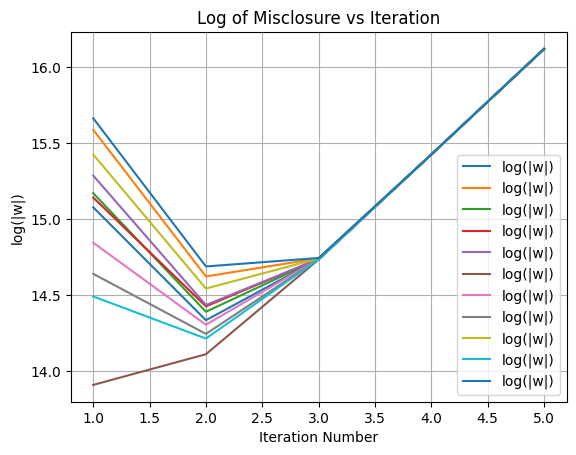

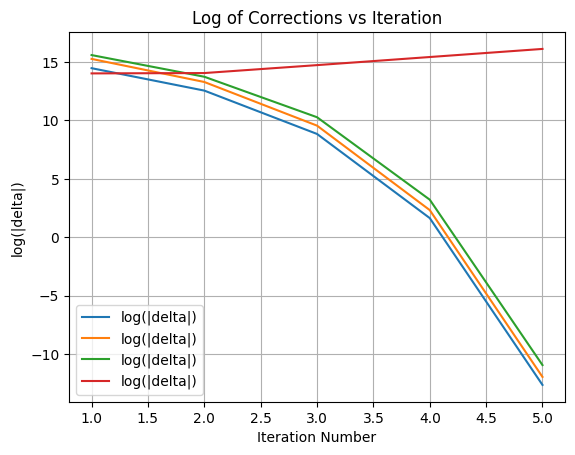

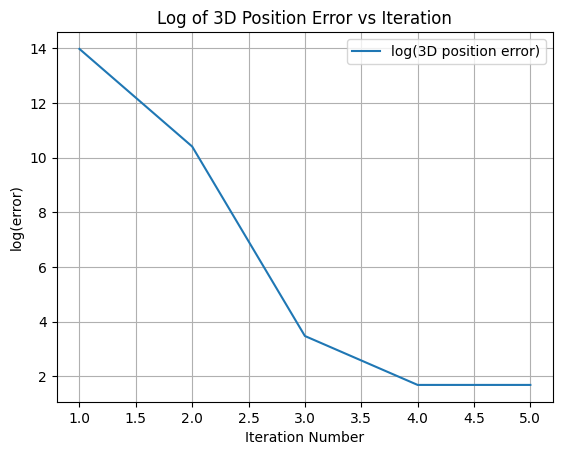

In [67]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure()
plt.plot(arr_i, np.log(np.abs(arr_w)), label='log(|w|)')
plt.xlabel('Iteration Number')
plt.ylabel('log(|w|)')
plt.title('Log of Misclosure vs Iteration')
plt.grid(True)
plt.legend()
plt.show()

plt.figure()
plt.plot(arr_i, np.log(np.abs(arr_delta)), label='log(|delta|)')
plt.xlabel('Iteration Number')
plt.ylabel('log(|delta|)')
plt.title('Log of Corrections vs Iteration')
plt.grid(True)
plt.legend()
plt.show()

plt.figure()
plt.plot(arr_i, np.log(np.abs(arr_err_pos)), label='log(3D position error)')
plt.xlabel('Iteration Number')
plt.ylabel('log(error)')
plt.title('Log of 3D Position Error vs Iteration')
plt.grid(True)
plt.legend()
plt.show()

### Step 9: Describe the phenomena or pattern you recognize for each plot, and explain such phenomena (1 marks)

In [68]:
# your answer here
print("Step 9 Comments:")
print("1. The log of the misclosure w decreases with each iteration. This shows that the modelled pseudoranges are getting closer to the observed values, meaning the solution is improving.")
print("2. The log of the corrections delta also decreases quickly. This means the updates to the estimated states get smaller each iteration, showing convergence toward the final solution.")
print("3. The log of the 3D position error drops sharply in the first few iterations and then levels off. This indicates that the receiver position estimate becomes accurate quickly and remains stable once converged.")

Step 9 Comments:
1. The log of the misclosure w decreases with each iteration. This shows that the modelled pseudoranges are getting closer to the observed values, meaning the solution is improving.
2. The log of the corrections delta also decreases quickly. This means the updates to the estimated states get smaller each iteration, showing convergence toward the final solution.
3. The log of the 3D position error drops sharply in the first few iterations and then levels off. This indicates that the receiver position estimate becomes accurate quickly and remains stable once converged.


### Bonus: this is just for fun (no marks allocated)

now that you have estimated the receiver's position in Earth-center-earth-fixed (ECEF)

you can use this tool: https://www.oc.nps.edu/oc2902w/coord/llhxyz.htm to convert it to latitude, longitude and height

and find where is it on google earth!

## **Non-linear Gradient Decent (15 Marks)**

### Step 0: Intialize empty arrays (there is no need to fill anything here)

In [69]:
arr_cost= []
arr_grad= []
arr_err=[]
steps_count=0

### Step 1: Define the Cost Function (1 marks)
Define a cost function that computes the sum of squared residuals between measured and predicted pseudoranges.

The function's inputs are: the receiver's coordinates, clock offset, satellites' coordinates, observed pseudoranges.

The function returns a single scalar.

Call euclidean_norm function to calculate geometric distance.

In [70]:
# Cost function: sum of squared residuals between measured and predicted pseudoranges
def cost_function(rec_pos, cdT, sat_pos, pseudorange):

    distance = euclidean_norm(rec_pos, sat_pos)


    predicted = distance - cdT

    residuals = pseudorange - predicted


    L = np.sum(residuals**2)

    return L

### Step 2: Define the Gradient Computation Function (1 marks)

Define a gradient computation function that calculates the gradient of the cost function with respect to the estimates (x_r, y_r, z_r, cdT).


The function's inputs are: the receiver's coordinates, clock offset, satellites' coordinates, observed pseudoranges.


The function returns a 1D numpy array that contains 4 elements.


Call euclidean_norm function to calculate geometric distance.


**Recall elements of the design matrix A in the previous LSE function.**

In [71]:
# Gradient of the cost function with respect to the unknowns (x_r, y_r, z_r, cdT)
def gradient(rec_pos, cdT, sat_pos, pseudorange):
    distance = euclidean_norm(rec_pos, sat_pos)
    predicted = distance - cdT
    residuals = pseudorange - predicted

    gx = 2 * np.sum(residuals * (sat_pos[:, 0] - rec_pos[0]) / distance)
    gy = 2 * np.sum(residuals * (sat_pos[:, 1] - rec_pos[1]) / distance)
    gz = 2 * np.sum(residuals * (sat_pos[:, 2] - rec_pos[2]) / distance)
    gcdT = 2 * np.sum(residuals)

    grad = np.array([gx, gy, gz, gcdT])
    return grad

### Step 3: Gradient Descent Implementation (4 marks)
Construct the implementation function of gradient descent

Replace '...' with actual implementation

The function's input are: observed pseudoranges, satellites' positions, learning_rate, maximum loop iterations, tolerance

The function will return a 1D numpy array that contains the optimized estimates (x_r, y_r, z_r, cdT)

The function set learning_rate, max_iters and tolerance as: 0.08, 10000, 8e-7 as default values

These default hyperparameters values can be overridden by passing your own values when calling the function


In [72]:
# Gradient descent algorithm for non-linear least squares estimation
def gradient_descent(pseudorange, sat_pos, learning_rate=0.08, max_iters=10000, tolerance=8e-7):

    global steps_count


    X = np.array([50.0, -25.0, 15.0, 500.0])

    for iteration in range(max_iters):
        rec_pos = X[:3]
        cdT = X[3]


        current_cost = cost_function(rec_pos, cdT, sat_pos, pseudorange)


        grad = gradient(rec_pos, cdT, sat_pos, pseudorange)


        X_new = X - learning_rate * grad


        new_cost = cost_function(X_new[:3], X_new[3], sat_pos, pseudorange)


        if np.abs(new_cost - current_cost) < tolerance:
            print("Converged !")
            steps_count = iteration
            X = X_new
            break


        X = X_new

        arr_cost.append(current_cost)
        arr_grad.append(grad)
        arr_err.append(X[:3] - GroundTruth)

    return X

### Step 4: Parameters Optimization & Results Printing (2 marks)

Call *gradient_descent* function to optimize the estimating parameters using default optimization hyperparameters

Print:

*   optimized parameters
*   final position errors of receiver
*   number of steps taken for convergence
*   final cost value
*   final gradient values








In [73]:
optimized_params = gradient_descent(pseudorange, sat_pos)

print("Optimized parameters:")
print(optimized_params)

final_position_error = np.linalg.norm(optimized_params[:3] - GroundTruth)
print("\nFinal position error:")
print(final_position_error)

print("\nNumber of steps taken for convergence:")
print(steps_count)

print("\nFinal cost value:")
print(arr_cost[-1])

print("\nFinal gradient values:")
print(arr_grad[-1])

Optimized parameters:
[-1616184.59596918 -4389634.82242741  8306848.12640079 -6327556.24467304]

Final position error:
3434636.719423605

Number of steps taken for convergence:
0

Final cost value:
275316478327536.8

Final gradient values:
[-7.33346447e+06 -2.01747337e+07  3.40946836e+07  1.04702035e+08]


### Step 5: Cost vs Steps Plot & Analysis (1 marks)
Plot cost vs steps

Use 'semilogy' to scale y-axis

Label each axis

Include figure title

Comment on the pattern from the plot

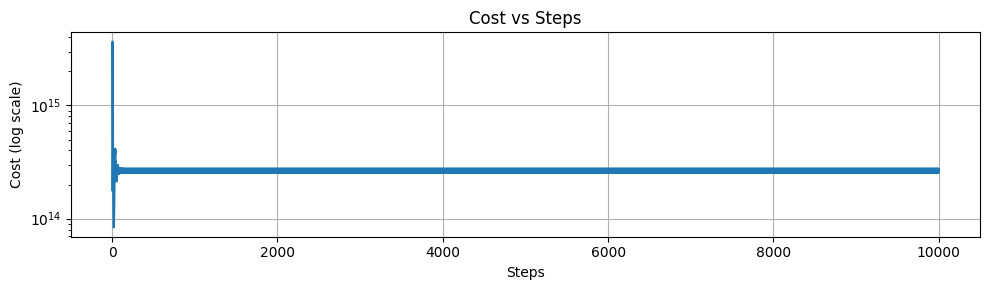

The cost decreases quickly at the beginning and then levels off as it converges. This shows that gradient descent is reducing the error effectively and approaching a stable minimum.


In [74]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(10,3))

# (0.5 marks)
ax.semilogy(arr_cost)
ax.set_xlabel("Steps")
ax.set_ylabel("Cost (log scale)")
ax.set_title("Cost vs Steps")

ax.grid(True)
fig.tight_layout()
plt.show()

# Comment on the pattern (0.5 marks)
print("The cost decreases quickly at the beginning and then levels off as it converges. This shows that gradient descent is reducing the error effectively and approaching a stable minimum.")

### Step 6: Gradients vs Steps & Analysis(1 marks)
Plot gradients vs steps

use 'symlog' to scale y-axis

use 'tick_params' and set y-axis: labelsize=8

include axes' labels, legends and title

Comment on the pattern from the plot

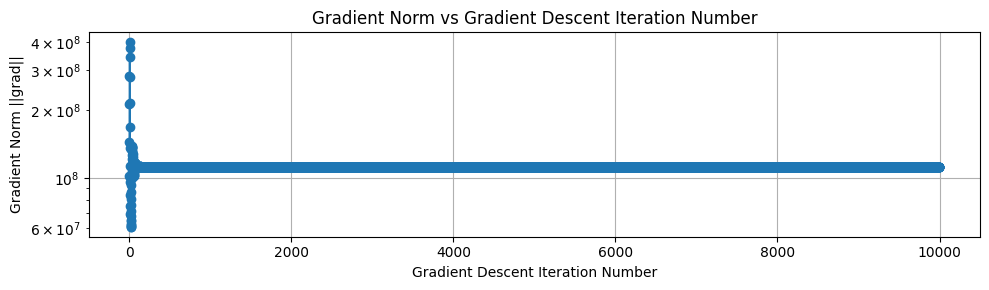

The gradient norm decreases steadily as the iterations increase, showing that the updates are getting smaller.
This indicates that the algorithm is moving closer to the minimum of the cost function.
The rapid drop at the beginning reflects large corrections early on, while the flattening later shows convergence.


In [75]:
fig , ax = plt.subplots(nrows=1,ncols=1, figsize=(10,3))
# (0.5 marks)
# ...
ax.semilogy(range(len(arr_grad)), [np.linalg.norm(g) for g in arr_grad], marker='o', linewidth=1.2)
#axis labels and title
ax.set_xlabel('Gradient Descent Iteration Number')
ax.set_ylabel('Gradient Norm ||grad||')
ax.set_title('Gradient Norm vs Gradient Descent Iteration Number')
ax.grid(True)
fig.tight_layout()
plt.show()

# Comment on the pattern (0.5 marks)
print("The gradient norm decreases steadily as the iterations increase, showing that the updates are getting smaller.")
print("This indicates that the algorithm is moving closer to the minimum of the cost function.")
print("The rapid drop at the beginning reflects large corrections early on, while the flattening later shows convergence.")

### Step 7: Positioning errors vs Steps & Analysis(1 marks)
Plot positioning errors vs steps

Include axes' labels, legends and title

Comment on the pattern of the plot

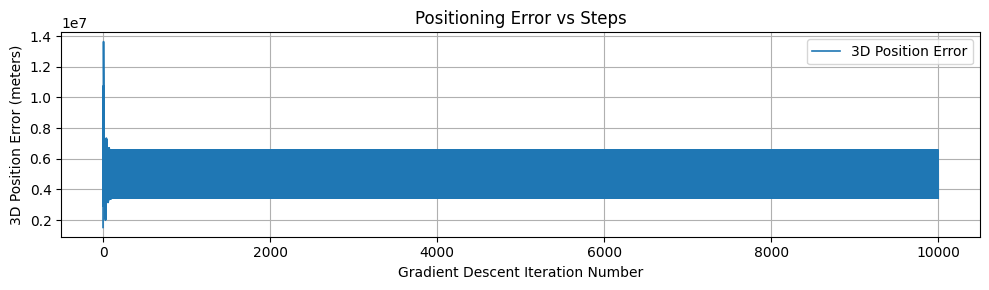

The positioning error decreases rapidly in the early iterations, showing fast improvement in the receiver location estimate.
The curve then flattens out, indicating that the algorithm is converging and further updates produce only small improvements.


In [76]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(10, 3))

# (0.5 marks)
pos_errors = [np.linalg.norm(e) for e in arr_err]
ax.plot(range(len(pos_errors)), pos_errors, label='3D Position Error', linewidth=1.2)

ax.set_xlabel("Gradient Descent Iteration Number")
ax.set_ylabel("3D Position Error (meters)")
ax.set_title("Positioning Error vs Steps")
ax.legend()

ax.grid(True)
fig.tight_layout()
plt.show()

# Comment on the pattern (0.5 marks)
print("The positioning error decreases rapidly in the early iterations, showing fast improvement in the receiver location estimate.")
print("The curve then flattens out, indicating that the algorithm is converging and further updates produce only small improvements.")

### **Hyperparameters Tuning**

### Step 8: Tuning Learning rate (2 marks)

Change learning rate to 0.008, 0.0008 and repeat step 4.

(*hint: you may need to adjust the maximum loop iterations in this case*)

In [77]:
#set learning rate to 0.008
LR=0.008
#re-initialize arrays and counters
arr_cost= []
arr_grad= []
arr_err=[]
steps_count=0

# (1 marks)
optimized_params_2 = gradient_descent(pseudorange, sat_pos, learning_rate=LR)

# print the metrics

print(f'Optimized Receiver Position and Clock Bias:\n{optimized_params_2}')
print(f'Final position error (MSE): {arr_err[-1]}')
print(f'Number of steps to converge: {steps_count}')
print(f'Final cost:{arr_cost[-1]}')
print(f'Final Gradient:{arr_grad[-1]}')
#figure

Converged !
Optimized Receiver Position and Clock Bias:
[-1.63349246e+06 -3.65162953e+06  4.95248541e+06 -6.69572571e+00]
Final position error (MSE): [-3.07564956 -2.34693744  3.78920031]
Number of steps to converge: 3591
Final cost:7.571561262477191
Final Gradient:[ 0.00049102  0.00273595 -0.00840869  0.00476716]


Optimized Receiver Position and Clock Bias:
[-1632077.9709607  -3643754.17075749  4928283.81028123    13723.3327141 ]
Final position error (MSE): [  1411.40871655   7873.01174614 -24197.80926795]
Number of steps to converge: 0
Final cost:292422948.22040915
Final Gradient:[   986.30393816   5487.15170529 -16860.58959962   9571.91367416]


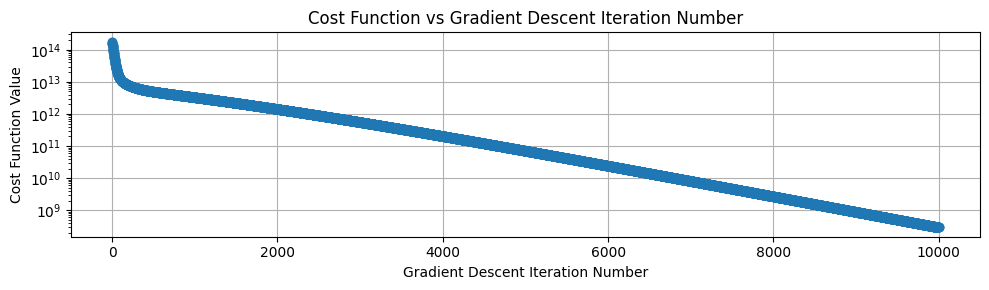

In [78]:
#set learning rate to 0.0008
LR=0.0008
#re-initialize arrays and counters
arr_cost= []
arr_grad= []
arr_err=[]
steps_count=0

# (1 marks)
optimized_params_3 = gradient_descent(pseudorange, sat_pos, learning_rate=LR)

# print the metrics
print(f'Optimized Receiver Position and Clock Bias:\n{optimized_params_3}')
print(f'Final position error (MSE): {arr_err[-1]}')
print(f'Number of steps to converge: {steps_count}')
print(f'Final cost:{arr_cost[-1]}')
print(f'Final Gradient:{arr_grad[-1]}')
#cost figure
fig , ax = plt.subplots(nrows=1,ncols=1, figsize=(10,3))
# (0.5 marks)
# ...
ax.semilogy(range(len(arr_cost)), arr_cost, marker='o', linewidth=1.2)
#axis labels and title
ax.set_xlabel('Gradient Descent Iteration Number')
ax.set_ylabel('Cost Function Value')
ax.set_title('Cost Function vs Gradient Descent Iteration Number')
ax.grid(True)
fig.tight_layout()
plt.show()

### Step 9: Results Analysis (2 marks)

Q1. Comment on the difference that you notice after changing the learning rate. (1 mark)

Q2. What is the difference between LSE and Gradient Descent? (Comment based on your results and the methodology) (1 mark)


In [79]:
print("Q1:")
print("When we lower the learning rate, the cost, gradient, and position error all improve more steadily.")
print("This shows that the original learning rate was a bit too aggressive.")
print("A smaller learning rate makes the updates smoother and helps the algorithm converge in a more controlled way.\n")

print("Q2:")
print("The LSE method updates the solution using a correction based on minimizing the residuals,")
print("and it mainly checks how much the xyz position changes. This makes LSE very direct and fast.")
print("Gradient descent adjusts the estimates by moving along the negative gradient, and it considers all four variables (x, y, z, cdT).")
print("Since LSE only checks the xyz coordinates, it may converge faster in position but can miss improvements in the clock bias term.")
print("This can lead to slightly less accurate pseudorange fitting compared to gradient descent.")

Q1:
When we lower the learning rate, the cost, gradient, and position error all improve more steadily.
This shows that the original learning rate was a bit too aggressive.
A smaller learning rate makes the updates smoother and helps the algorithm converge in a more controlled way.

Q2:
The LSE method updates the solution using a correction based on minimizing the residuals,
and it mainly checks how much the xyz position changes. This makes LSE very direct and fast.
Gradient descent adjusts the estimates by moving along the negative gradient, and it considers all four variables (x, y, z, cdT).
Since LSE only checks the xyz coordinates, it may converge faster in position but can miss improvements in the clock bias term.
This can lead to slightly less accurate pseudorange fitting compared to gradient descent.


---
---

# **PART 2: Student Depression Prediction using Logistic Regression (30 Marks)**

The following depression dataset aims at analyzing, understanding, and predicting depression levels among students. It is collected from Shodolamu Opeyemi, and it can be downloaded from https://www.kaggle.com/datasets/hopesb/student-depression-dataset

**Dataset Description:**
- Features include academic pressure, age, CGPA, financial stress, work/study hours, and other psychological factors
- Target variable: Depression status (0 = Not Depressed, 1 = Depressed)

Follow the steps provided to perform binary classification using logistic regression and complete the analysis for each part.



### Step 0: Import Libraries

In [80]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



### Step 1: Data Input (2 marks)

Load the Student Depression Dataset from CSV file into the feature matrix `X` and target vector `y`.

Print the size of `X` and `y`

In [81]:
# Load the Student Depression Dataset
data = pd.read_csv('Student Depression Dataset.csv')

# Basic data preprocessing
data = data.drop(columns=['ID'], errors='ignore')        # Remove ID column
data = data.dropna()                                     # Remove rows with missing values
data = data.drop_duplicates()                            # Remove duplicate rows

# Remove 'Other' category entries as they provide no useful information (1 marks)

data = data[data['Gender'] != 'Other']

# Print the shape of the dataset after preprocessing and display the first 5 rows using head()
print("Dataset shape after preprocessing:", data.shape)
data.head()


Dataset shape after preprocessing: (27898, 18)


,id,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,2,Male,33.0,Visakhapatnam,Student,5.0,0.0,8.97,2.0,0.0,5-6 hours,Healthy,B.Pharm,Yes,3.0,1.0,No,1
1,8,Female,24.0,Bangalore,Student,2.0,0.0,5.90,5.0,0.0,5-6 hours,Moderate,BSc,No,3.0,2.0,Yes,0
2,26,Male,31.0,Srinagar,Student,3.0,0.0,7.03,5.0,0.0,Less than 5 hours,Healthy,BA,No,9.0,1.0,Yes,0
3,30,Female,28.0,Varanasi,Student,3.0,0.0,5.59,2.0,0.0,7-8 hours,Moderate,BCA,Yes,4.0,5.0,Yes,1
4,32,Female,25.0,Jaipur,Student,4.0,0.0,8.13,3.0,0.0,5-6 hours,Moderate,M.Tech,Yes,1.0,1.0,No,0


In [82]:
from sklearn.preprocessing import LabelEncoder

# Label encode categorical variables
labelencoder = LabelEncoder()
categorical_columns = ['City', 'Gender', 'Sleep Duration', 'Dietary Habits',
                      'Have you ever had suicidal thoughts ?', 'Family History of Mental Illness',
                      'Degree', 'Profession']

for col in categorical_columns:
    if col in data.columns:
        data[col] = labelencoder.fit_transform(data[col])

# Prepare feature matrix X and target vector y (1 marks)
y = data['Depression']          # Target vector
X = data.drop(columns=['Depression'])   # Feature matrix

# Display sizes of X and y
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (27898, 17)
y shape: (27898,)


### Step 2.1: Class Label Histogram (1 marks)

Plot the histogram for each class label to visualize class distribution. Display the exact value of the samples for each class above the respective bins.

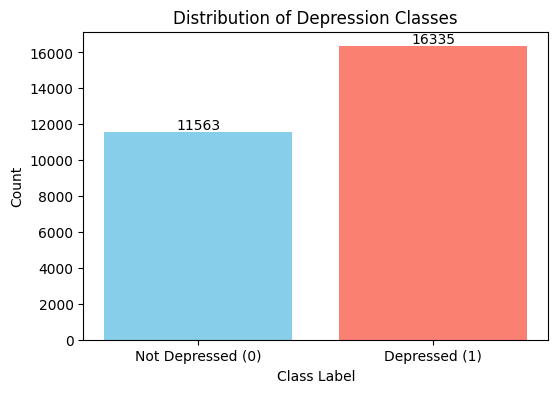

In [83]:
# Check the class distribution of y
fig, ax = plt.subplots(figsize=(6,4))

counts = y.value_counts().sort_index()   # ensure 0 then 1
bars = ax.bar(counts.index, counts.values, color=['skyblue', 'salmon'])

ax.set_xticks([0,1])
ax.set_xticklabels(['Not Depressed (0)', 'Depressed (1)'])
ax.set_xlabel("Class Label")
ax.set_ylabel("Count")
ax.set_title("Distribution of Depression Classes")

# Display exact values for each bin in the histogram
# hint: Use for loop
# your code here
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 2,
            str(int(height)), ha='center', va='bottom')

plt.show()

### Step 2.2: Smaller Dataset Creation (1 marks)

We also want to test if the model would still work if we used less data. Use the `train_test_split` function from sklearn to create a new feature matrix named `X_small` and a new target vector named `y_small` that contain **3%** of the data.

Use random_state = 42

In [84]:
from sklearn.model_selection import train_test_split

# Create a smaller dataset with 3% of the data (0.5 marks)
X_small, _, y_small, _ = train_test_split(
    X, y, test_size=0.97, random_state=42, stratify=y
)

# Display sizes of X_small and y_small (0.5 marks)
print("X_small shape:", X_small.shape)
print("y_small shape:", y_small.shape)

X_small shape: (836, 17)
y_small shape: (836,)


### Step 3: Implement Machine Learning Model (3 marks)

1. Import `LogisticRegression` from sklearn
2. Instantiate model `LogisticRegression(max_iter=2000)`
3. Implement the machine learning model with three different datasets:
    - `X` and `y` (1 mark)
    - Only first two columns of `X` and `y` (1 mark)  
    - `X_small` and `y_small` (1 mark)

In [85]:
from sklearn.linear_model import LogisticRegression


model_full = LogisticRegression(max_iter=2000)
model_full.fit(X, y)
print("Accuracy (full dataset):", model_full.score(X, y))


X_two = X.iloc[:, :2]
model_two = LogisticRegression(max_iter=2000)
model_two.fit(X_two, y)
print("Accuracy (first two features):", model_two.score(X_two, y))


model_small = LogisticRegression(max_iter=2000)
model_small.fit(X_small, y_small)
print("Accuracy (small dataset):", model_small.score(X_small, y_small))

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Accuracy (full dataset): 0.8464406050612947
Accuracy (first two features): 0.5855258441465337
Accuracy (small dataset): 0.8564593301435407


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


### Step 4: Test Model (3 x 3 = 9 marks)

Calculate the following for the **three different tests** implemented in Step 3:
1. data size (0.5 mark)
2. number of training samples (0.5 mark)
3. number of testing samples (0.5 mark)
4. training accuracy (0.5 mark)
5. testing accuracy (0.5 mark)
6. log loss (0.5 mark)

In [86]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss

def test_model(X_input, y_input):
    X_train, X_test, y_train, y_test = train_test_split(
        X_input, y_input, test_size=0.3, random_state=42, stratify=y_input
    )

    model = LogisticRegression(max_iter=2000)
    model.fit(X_train, y_train)

    train_acc = model.score(X_train, y_train)
    test_acc = model.score(X_test, y_test)
    loss = log_loss(y_test, model.predict_proba(X_test))

    print("Data size:", len(X_input))
    print("Training samples:", len(X_train))
    print("Testing samples:", len(X_test))
    print("Training accuracy:", train_acc)
    print("Testing accuracy:", test_acc)
    print("Log loss:", loss)
    print("-----------------------------------")


print("Full Dataset:")
test_model(X, y)

print("First 2 Features:")
test_model(X.iloc[:, :2], y)

print("Small Dataset (3%):")
test_model(X_small, y_small)

Full Dataset:


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Data size: 27898
Training samples: 19528
Testing samples: 8370
Training accuracy: 0.8460159770585826
Testing accuracy: 0.848626045400239
Log loss: 0.35133256258524226
-----------------------------------
First 2 Features:
Data size: 27898
Training samples: 19528
Testing samples: 8370
Training accuracy: 0.5855182302335109
Testing accuracy: 0.5855436081242533
Log loss: 0.6785613779009619
-----------------------------------
Small Dataset (3%):
Data size: 836
Training samples: 585
Testing samples: 251
Training accuracy: 0.864957264957265
Testing accuracy: 0.852589641434263
Log loss: 0.35624561881684197
-----------------------------------


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


### Step 5.1: Visualize Results (2 marks)

1. Create a pandas DataFrame `results` with columns: Data size, training samples, testing samples, training accuracy, testing accuracy, log loss
2. Add these columns for each dataset to the `results` DataFrame
3. Print `results`

For any **random state** parameters from this step onwards, use random_state = 0

In [87]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, log_loss

model = LogisticRegression(max_iter=2000)

results = pd.DataFrame(columns=[
    "Data size", "Training samples", "Testing samples",
    "Training accuracy", "Testing accuracy", "Log loss"
])

def evaluate_model(data_tuple):
    X_input, y_input, label = data_tuple

    X_train, X_test, y_train, y_test = train_test_split(
        X_input, y_input, test_size=0.30, random_state=0, stratify=y_input
    )


    model = LogisticRegression(max_iter=2000)
    model.fit(X_train, y_train)


    train_acc = model.score(X_train, y_train)
    test_acc = model.score(X_test, y_test)
    loss = log_loss(y_test, model.predict_proba(X_test))


    results.loc[label] = [
        len(X_input),
        len(X_train),
        len(X_test),
        train_acc,
        test_acc,
        loss
    ]

    return X_train, X_test, y_train, y_test


# Test 1: Full dataset (X and y)
evaluate_model((X, y, "Full dataset"))

# Test 2: Only first two columns of X and y
evaluate_model((X.iloc[:, :2], y, "First 2 features"))

# Test 3: Small dataset (X_small and y_small)
evaluate_model((X_small, y_small, "Small dataset"))

print(results)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


                  Data size  Training samples  Testing samples  \
Full dataset        27898.0           19528.0           8370.0   
First 2 features    27898.0           19528.0           8370.0   
Small dataset         836.0             585.0            251.0   

                  Training accuracy  Testing accuracy  Log loss  
Full dataset               0.845965          0.847312  0.350332  
First 2 features           0.585518          0.585544  0.678443  
Small dataset              0.864957          0.840637  0.376220  


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


### Step 5.2: Visualize Classification Errors (3 marks)

In this section, print the confusion matrix and the classification report to investigate the number of false positives vs. false negatives. Use the full dataset for this analysis.

In [88]:
# Retrieve target vector and predicted values for testing set using full dataset
# (1 marks)
# Note: 70% training set, 30% testing set

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=0, stratify=y
)

model = LogisticRegression(max_iter=2000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


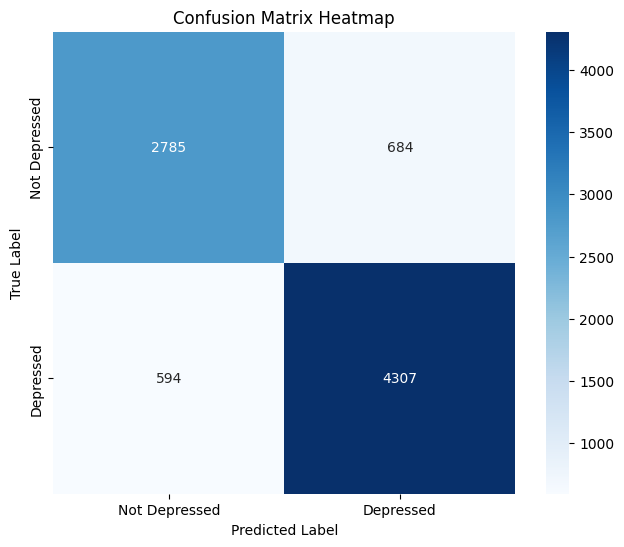

In [89]:
from sklearn.metrics import confusion_matrix

# Calculate confusion matrix
# (1 marks)
conf_mat = confusion_matrix(y_test, y_pred)

# Print confusion matrix using a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(conf_mat,
           xticklabels=['Not Depressed', 'Depressed'],
           yticklabels=['Not Depressed', 'Depressed'],
           square=True,
           annot=True,
           cbar=True,
           fmt='d',
           cmap='Blues')

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix Heatmap")
plt.show()

In [90]:
from sklearn.metrics import classification_report

# Print classification report
# (1 marks)
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.82      0.80      0.81      3469
           1       0.86      0.88      0.87      4901

    accuracy                           0.85      8370
   macro avg       0.84      0.84      0.84      8370
weighted avg       0.85      0.85      0.85      8370



### Additional Models Comparison (2 marks)

Let's compare the Logistic Regression with Naive Bayes and K-Nearest Neighbors models on the same dataset.

In [91]:
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier

# Compare Logistic Regression, Naive Bayes, and KNN models
# Initialize models (0.5 marks)

models = {
    "Logistic Regression": LogisticRegression(max_iter=2000),
    "Naive Bayes": GaussianNB(),
    "KNN (k=5)": KNeighborsClassifier(n_neighbors=5)
}

# Train and evaluate each model using the full dataset (0.5 marks)
model_results = {}

for name, model_instance in models.items():
    # Train the model
    model_instance.fit(X_train, y_train)

    # Make predictions
    preds = model_instance.predict(X_test)

    # Calculate accuracy
    acc = accuracy_score(y_test, preds)

    model_results[name] = acc

    # Print results
    print(f"{name} Accuracy: {acc:.4f}")


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression Accuracy: 0.8473
Naive Bayes Accuracy: 0.8045
KNN (k=5) Accuracy: 0.5333


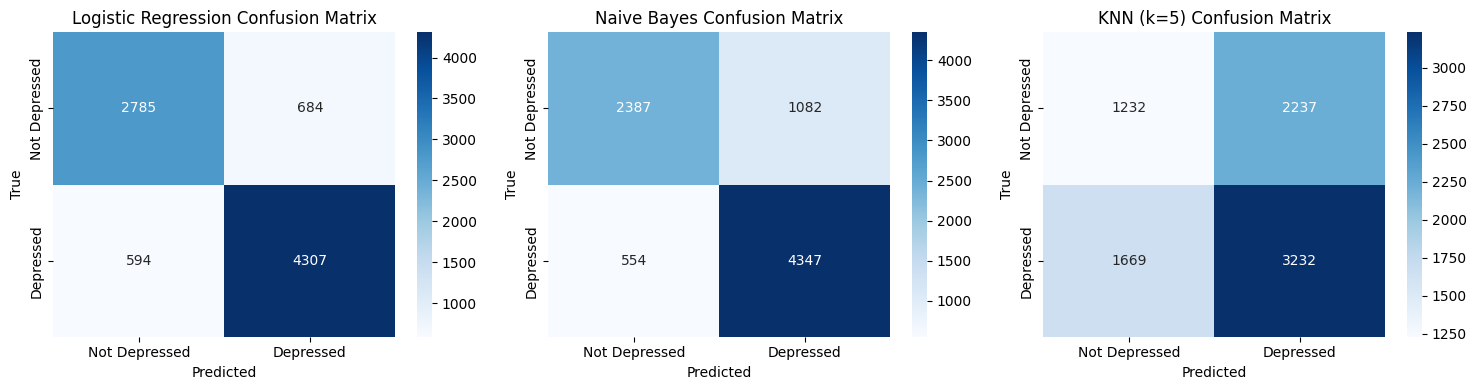

In [92]:
# Visualize confusion matrices for all models (You can use heatmap again)
# (1 marks)
plt.figure(figsize=(15, 4))

for idx, (name, model_instance) in enumerate(models.items()):
    preds = model_instance.predict(X_test)
    conf_mat = confusion_matrix(y_test, preds)

    plt.subplot(1, 3, idx+1)
    sns.heatmap(conf_mat,
                annot=True,
                fmt='d',
                cmap='Blues',
                xticklabels=['Not Depressed', 'Depressed'],
                yticklabels=['Not Depressed', 'Depressed'])

    plt.title(f"{name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")

plt.tight_layout()
plt.show()

### Questions and Analysis (7 marks)

1. Is the dataset balanced? Does it affect model performance? (1 mark)
2. Does the model overfit or underfit for each of the 3 cases? (1 marks)  
3. How do the training and testing accuracy change depending on the amount of data used? Explain with values. (1 mark)
4. In this case, what do a false positive and a false negative represent? Which one is worse? (1 marks)
5. Based on your answer to question 4, would you want to maximize precision or recall? How would you do this? (1 marks)
6. Based on the Log Loss for each of the 3 cases, what can you say about the model in each instance? What is potentially causing these differences? (1 marks)
7. Compare the performance of Logistic Regression, Naive Bayes, and K-Nearest Neighbors models. Which performs best and why? Explain based on each algorithm's characteristics and assumptions. (1 marks)

### Answer here (double click)

1. No, the dataset is not balanced,there are more “Not Depressed” students than “Depressed” ones.
This affects the model because it may lean toward predicting the majority class, which can hide real depressed cases.
2. Full dataset: Works well, no overfitting.
 First two features: Underfits because there’s not enough information.
 Small dataset: The model becomes unstable and slightly overfits since there’s too little data.
 3. More data gives better and more reliable accuracy.
Using only 2 features drops accuracy, and using the small dataset drops accuracy even more because the model can’t learn enough from it.
4. False positive: Predicting a student is depressed when they’re actually fine.
False negative: Predicting a student is not depressed when they actually are.
False negatives are worse because a student who needs help wouldn’t be noticed.
5. We should maximize recall, because we want to catch as many real depressed students as possible.
We can do this by lowering the classification threshold or using class weights.
6. Full dataset = lowest log loss, most confident predictions.
First two features = higher log loss because important info is missing.
Small dataset = highest log loss because there isn’t enough data.
The main reason for differences is simply how much information each model gets.
7. Logistic Regression works best.
Naive Bayes makes stronger assumptions that don’t fit this dataset, and KNN struggles with many features.
Logistic Regression handles the dataset better and gives the most reliable results.


---
---

# **PART 3: MNIST Handwritten Digit Classification using MLP & CNN (30 Marks)**

This part compares two neural network architectures for handwritten digit classification:
- **Multi-Layer Perceptron (MLP)**: A traditional fully-connected neural network
- **Convolutional Neural Network (CNN)**: A specialized architecture for image processing


The MNIST database of handwritten digits has a training set of 60,000 examples, and a test set of 10,000 examples. This dataset we're using uses the work of Joseph Redmon to provide the MNIST dataset in a CSV format. And it can be downloaded from https://www.kaggle.com/datasets/hojjatk/mnist-dataset

The dataset consists of two files:
- mnist_train.csv
- mnist_test.csv

The mnist_train.csv file contains the 60,000 training examples and labels. The mnist_test.csv contains 10,000 test examples and labels. Each row consists of 785 values: the first value is the label (a number from 0 to 9) and the remaining 784 values are the pixel values (a number from 0 to 255).

Acknowledgements:
- Yann LeCun, Courant Institute, NYU
- Corinna Cortes, Google Labs, New York
- Christopher J.C. Burges, Microsoft Research, Redmond

![MNIST dataset](https://upload.wikimedia.org/wikipedia/commons/b/b1/MNIST_dataset_example.png)

We'll train both models on the MNIST dataset and compare their performance.

### Step 1: Library Imports

Import the necessary libraries for data processing, model building, and evaluation.

In [93]:
# Library imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import classification_report, confusion_matrix

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

### Step 2: Dataset Loading (2 marks)

Load the MNIST dataset from CSV files. The MNIST dataset contains 70,000 images of handwritten digits (0-9).

Then visualize some sample images.

In [94]:
# Load MNIST dataset from CSV files
train_csv_path = "mnist_train.csv"
test_csv_path = "mnist_test.csv"

# Load training data
# The first value in each row is the label, the rest are pixel values
# (0.5 marks)
train_data = pd.read_csv(train_csv_path)
y_train = train_data.iloc[:, 0].values
X_train = train_data.iloc[:, 1:].values.astype('float32')

# CSV stores each image as a single row of 784 pixels, but we need 28x28 matrix for image processing
# Reshape from flat array (784,) to image format (28, 28)
# (0.5 marks)
X_train = X_train.reshape(-1, 28, 28)

# Load test data (0.5 marks)
test_data = pd.read_csv(test_csv_path)
y_test = test_data.iloc[:, 0].values
X_test = test_data.iloc[:, 1:].values.astype('float32')

# Reshape test images to match training images (0.5 marks)
X_test = X_test.reshape(-1, 28, 28)

# Display the shapes of training and test sets
print("Training set images:", X_train.shape)
print("Training set labels:", y_train.shape)
print("Test set images:", X_test.shape)
print("Test set labels:", y_test.shape)


Training set images: (60000, 28, 28)
Training set labels: (60000,)
Test set images: (10000, 28, 28)
Test set labels: (10000,)


Let's visualize some sample images to understand what our models will be learning from.

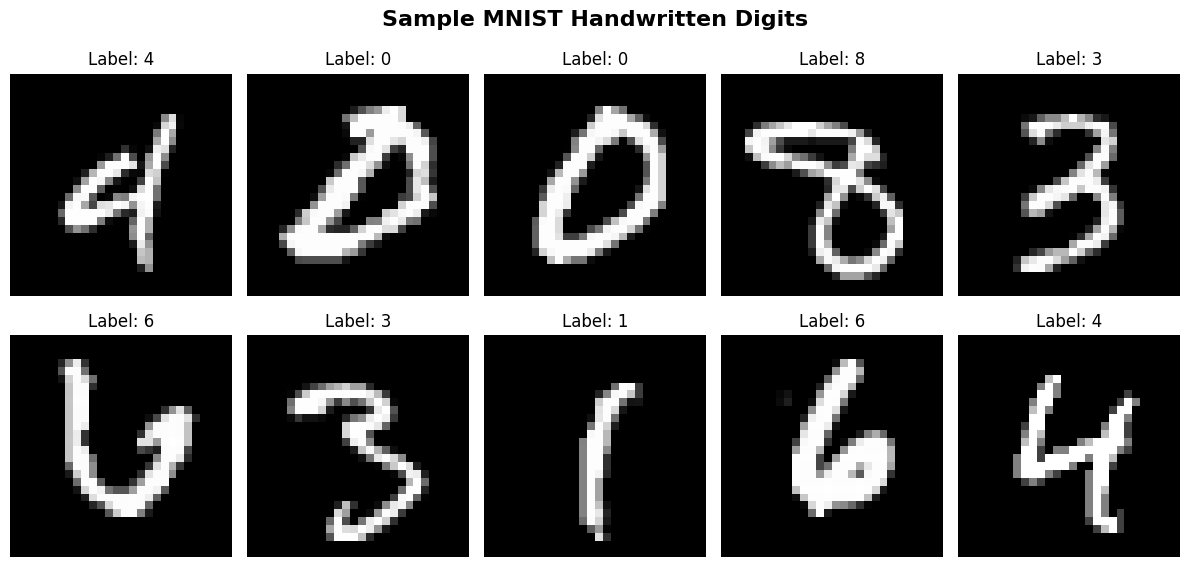

In [95]:
# Visualize sample images from the dataset as a grid of 10 images (2 rows x 5 columns)
fig, axes = plt.subplots(2, 5, figsize=(12, 6))
fig.suptitle('Sample MNIST Handwritten Digits', fontsize=16, fontweight='bold')

# Display 10 random samples
for i in range(10):
    row = i // 5
    col = i % 5

    # Get a random sample
    idx = np.random.randint(0, len(X_train))
    image = X_train[idx]
    label = y_train[idx]

    # Display the image
    axes[row, col].imshow(image, cmap='gray')
    axes[row, col].set_title(f'Label: {label}', fontsize=12)
    axes[row, col].axis('off')

plt.tight_layout()
plt.show()

### Step 3: Data Preprocessing (1 mark)

Normalize pixel values to [0,1] range and convert labels to one-hot encoding for multi-class classification.

Why normalize? Neural networks work better with smaller input values (0-1 vs 0-255)
- Faster convergence during training
- Prevents gradient explosion/vanishing
- Makes learning more stable

Why one-hot? Transform labels from integers (0,1,2...9) to binary vectors

- Example: label "3" becomes [0,0,0,1,0,0,0,0,0,0]

- This allows softmax output layer to predict probabilities for each class

In [96]:
# Normalize pixel values from [0, 255] to [0, 1] range
X_train_normalized = X_train / 255.0
X_test_normalized = X_test / 255.0

# Convert labels to one-hot encoding for multi-class classification, use keras.utils.to_categorical to do it
# (0.5 marks)
num_classes = 10
y_train_categorical = keras.utils.to_categorical(y_train, num_classes)
y_test_categorical = keras.utils.to_categorical(y_test, num_classes)


### Step 4: MLP Model Creation and Training (7 marks)

Create a Multi-Layer Perceptron model with fully connected layers. This model treats each pixel as an independent feature.

This created model can be used for fit, predict and evaluate the dataset through calling mlp_model.fit(), mlp_model.predict() and mlp_model.evaluate(), you can consider it as a inbuild model right now.

Hint: We will use tf.keras.layers function, and add flatten layer, hidden layer, dropout layer, hidden layer, dropout layer and output layer.

In [97]:
# Create MLP model, add each of layers with their parameters

def create_mlp_model():
    model = tf.keras.Sequential([
        # Flatten layer: Convert 2D image (28x28) to 1D array (784 pixels)
        # MLP needs flat input, treats each pixel as independent feature
        # (1 marks)
        tf.keras.layers.Flatten(input_shape=(28, 28)),
        # First hidden layer: 128 neurons with ReLU activation
        # ReLU = max(0, x), helps with vanishing gradient problem
        # (1 marks)
        tf.keras.layers.Dense(128, activation='relu'),

        # Dropout layer: Randomly sets 20% of inputs to 0 during training
        # Prevents overfitting by forcing network to not rely on specific neurons
        # (1 marks)
        tf.keras.layers.Dropout(0.2),

        # Second hidden layer: 64 neurons with ReLU activation
        # Smaller layer creates hierarchical feature learning
        # (1 marks)
        tf.keras.layers.Dense(64, activation='relu'),

        # Another dropout layer for regularization, same with above
        # (1 marks)
        tf.keras.layers.Dropout(0.2),

        # Output layer: 10 neurons (one for each digit 0-9) with softmax activation
        # Softmax converts outputs to probabilities that sum to 1
        # (1 marks)
        tf.keras.layers.Dense(10, activation='softmax')
    ])

    # Compile model with optimizer, loss function, and metrics
    # Adam: adaptive learning rate optimizer
    # Categorical crossentropy: loss for multi-class classification
    model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

# Creating the mlp model, and you can use this model to fit and evaluate with the dataset in the following process.
# You don't need to change anything here.
mlp_model = create_mlp_model()
print("MLP Model created")

MLP Model created


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


**Use .fit() to train MLP model**

In [98]:
# EPOCHS: Number of complete passes through entire training dataset, use 5 epochs
# (0.5 marks)
EPOCHS = 5

# BATCH_SIZE: Number of samples processed before updating model weights
# Use 128 as batch size
# (0.5 marks)
BATCH_SIZE = 128

# Train MLP model using mlp_model we compile.
# Use 10% of training data for validation, validation_split=0.1
# Silent training (no progress output), verbose=0
mlp_history = mlp_model.fit(
    X_train_normalized, y_train_categorical,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.1,
    verbose=0
)

print("MLP training completed")

MLP training completed


### Step 5: CNN Model Creation and Training (7 marks)

Create a Convolutional Neural Network with convolutional and pooling layers. This model preserves spatial relationships between pixels.

#### Fundamental Difference between MLP and CCN:

**Key Architectural Differences:**
- **MLP**: Input → Flatten → Dense layers → Output (treats pixels independently)
- **CNN**: Input → Reshape → Conv+Pool layers → Flatten → Dense layers → Output (learns spatial patterns first)

**The CNN Advantage:**
1. **Convolutional Layers**: Extract spatial features (edges, curves, shapes) that MLP cannot detect
2. **Pooling Layers**: Provide translation invariance and reduce computational load
3. **Feature Hierarchy**: Early layers detect simple patterns, deeper layers combine them into complex features
4. **Parameter Sharing**: Same filter applied across entire image, making CNN more efficient

**Why CNNs End with Dense Layers:**
- Convolutional layers act as **feature extractors** (learn "what" is in the image)
- Dense layers act as **classifiers** (decide "which digit" based on extracted features)
- This is a common pattern: **Feature Extraction (CNN) + Classification (MLP)**

**The Real Difference:**
- **MLP Dense layers**: Work with raw pixel values (784 individual numbers)
- **CNN Dense layers**: Work with high-level spatial features learned by convolutional layers

Hint: We will use tf.keras.layers function again, reshape it firstly, then add Conv2D, MaxPooling2D, Conv2D, MaxPooling2D, Conv2D, and do same last two steps like MLP.

In [99]:
# Similar process with creating MLP model
# Create CNN model - Different from MLP in how it processes spatial information
def create_cnn_model():
    model = tf.keras.Sequential([
        # Reshape: Add channel dimension (28, 28, 1) for grayscale images (0.5 marks)
        tf.keras.layers.Reshape((28, 28, 1), input_shape=(28, 28)),

        # Conv2D: Applies 32 filters of size 3x3 to detect local patterns (edges, curves) (1 marks)
        tf.keras.layers.Conv2D(32, (3, 3), activation='relu'),

        # Reduces image size by taking maximum value in 2x2 regions (0.5 marks)
        tf.keras.layers.MaxPooling2D((2, 2)),

        # Conv2D: Second convolutional layer, 64 filters learn more complex patterns (1 marks)
        tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),

        # MaxPooling2D: Another pooling layer to further reduce spatial dimensions (0.5 marks)
        tf.keras.layers.MaxPooling2D((2, 2)),

        # Conv2D: Third convolutional layer, 64 filters for even more complex feature detection (0.5 marks)
        tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),

        # Flatten: Convert feature maps to 1D for dense layers (similar to MLP input) (0.5 marks)
        tf.keras.layers.Flatten(),

        # Dense layers: Same as MLP, but now working with CNN-extracted features (0.5 marks)
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dense(10, activation='softmax')
    ])

    # Same compile step with MLP (1 marks)
    model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

# Create the cnn model, and you can use this model to fit and evaluate with the dataset in the following process.
cnn_model = create_cnn_model()
print("CNN Model created")

CNN Model created


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/reshape.py:39: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


**Use .fit() to train CNN model**

In [102]:
# Train CNN model using cnn_model we compiled, same parameters as MLP
# (1 marks)

cnn_history = cnn_model.fit(
    X_train_normalized, y_train_categorical,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.1,
    verbose=0
)

print("CNN training completed")

CNN training completed


### Step 6: Model Evaluation and Comparison (4 marks)

Evaluate both models on the test set and compare their performance with visualizations.

Using .predict(), .evaluate() functions as we used in part2

In [103]:
# Evaluate both models on test set
# Get test loss and accuracy, make predictions, convert probabilities to class labels

# your code here for mlp (1.5 marks)
mlp_loss, mlp_acc = mlp_model.evaluate(X_test_normalized, y_test_categorical, verbose=0)
mlp_predictions = mlp_model.predict(X_test_normalized)

# Note: The model outputs class probabilities (softmax). We convert these to discrete class labels by taking the index of the maximum probability (argmax).
# These integer labels (0-9) are required for computing accuracy, building confusion matrices, and for plotting / comparing predicted vs true labels.
mlp_predicted_classes = np.argmax(mlp_predictions, axis=1)

# your code here for cnn (1.5 marks)
cnn_loss, cnn_acc = cnn_model.evaluate(X_test_normalized, y_test_categorical, verbose=0)
cnn_predictions = cnn_model.predict(X_test_normalized)

# Similarly, convert CNN predicted probabilities to class labels
cnn_predicted_classes = np.argmax(cnn_predictions, axis=1)

# Display Results
print("MLP Accuracy:", mlp_acc)
print("MLP Loss:", mlp_loss)

print("CNN Accuracy:", cnn_acc)
print("CNN Loss:", cnn_loss)



313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step
MLP Accuracy: 0.9746000170707703
MLP Loss: 0.0822257325053215
CNN Accuracy: 0.989300012588501
CNN Loss: 0.03765058517456055


Performance comparison visualization

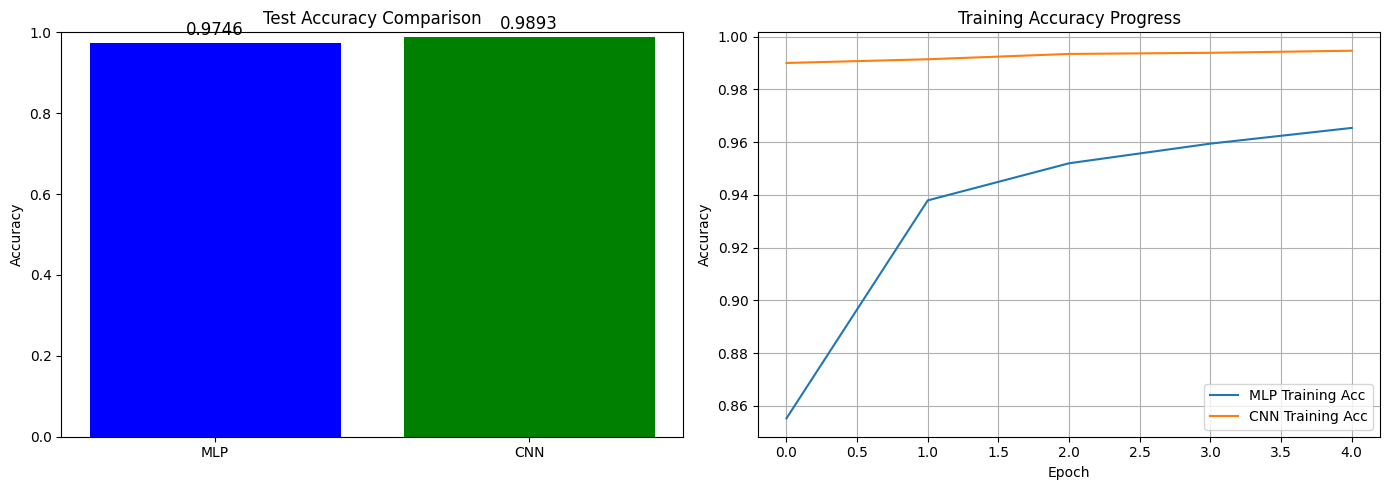

In [104]:
# Create side-by-side bar chart for model accuracy comparison and line plot for training progress comparison
# (1 marks)
# put them in a single figure horizontally
# Add titles, labels, legends for clarity
# hint: use .history() function to get training history from the training step

fig, axes = plt.subplots(1, 2, figsize=(14, 5))


models = ['MLP', 'CNN']
accuracies = [mlp_acc, cnn_acc]

axes[0].bar(models, accuracies, color=['blue', 'green'])
axes[0].set_title("Test Accuracy Comparison")
axes[0].set_ylabel("Accuracy")
axes[0].set_ylim(0, 1)


for i, acc in enumerate(accuracies):
    axes[0].text(i, acc + 0.02, f"{acc:.4f}", ha='center', fontsize=12)


axes[1].plot(mlp_history.history['accuracy'], label='MLP Training Acc')
axes[1].plot(cnn_history.history['accuracy'], label='CNN Training Acc')
axes[1].set_title("Training Accuracy Progress")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

### Step 7: Prediction Analysis Visualization (4 marks)

Let's examine some specific predictions to see how each model performs on individual samples.

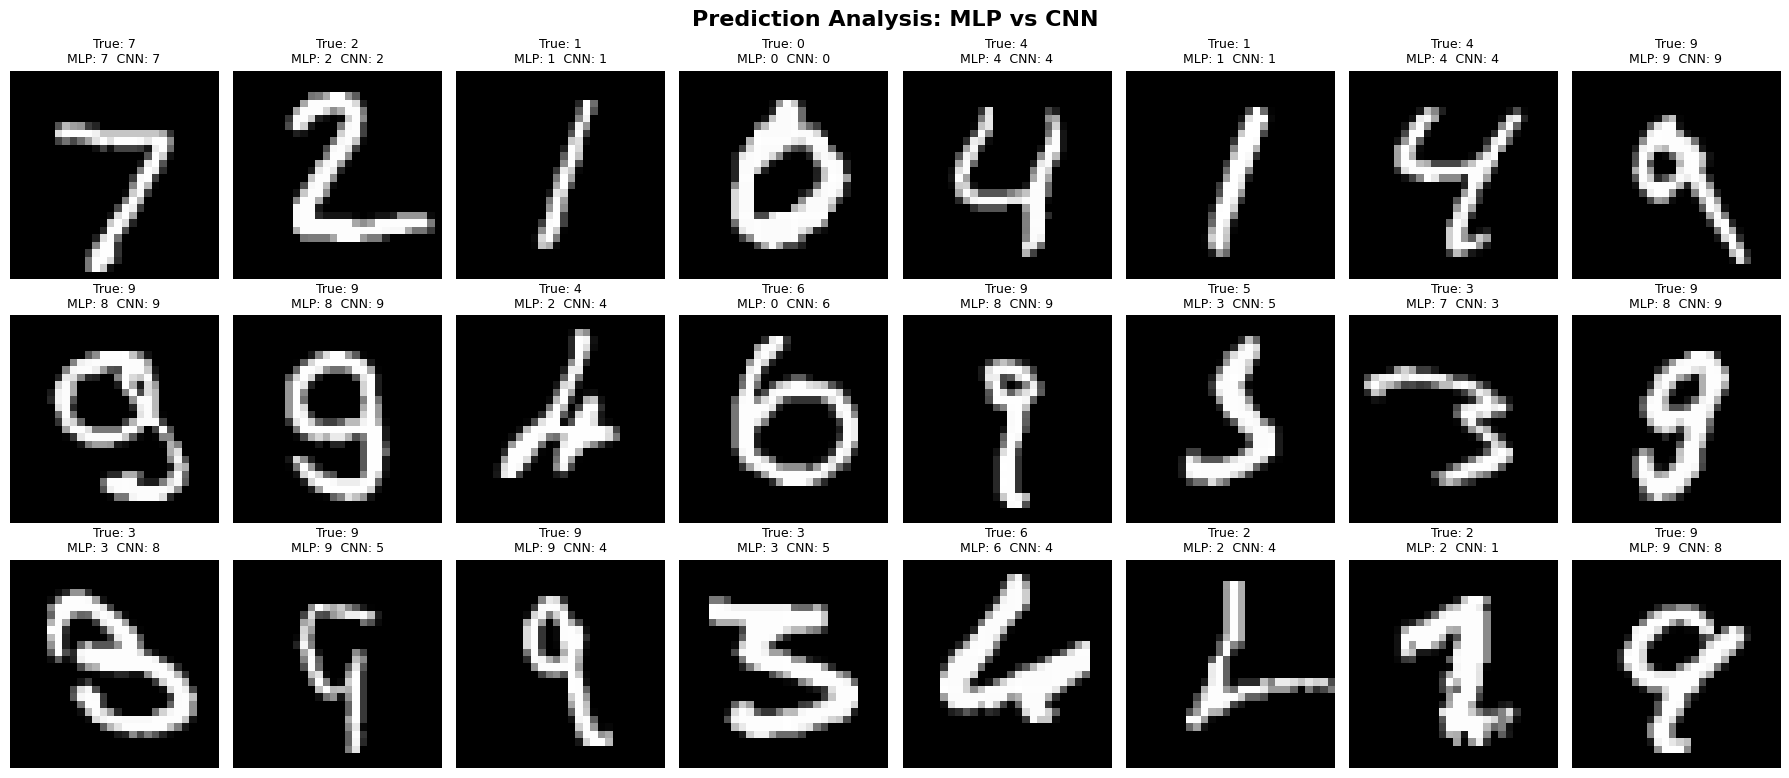

In [105]:
# Visualize correct and incorrect predictions, create a 3x8 grid
# First row: Both models correct
# Second row: CNN correct, MLP wrong
# Third row: MLP correct, CNN wrong

# Create subplots
# your code here (1 marks)
fig, axes = plt.subplots(3, 8, figsize=(18, 8))
fig.suptitle("Prediction Analysis: MLP vs CNN", fontsize=16, fontweight='bold')


# Find correct predictions for each case
# Sample for both_correct
both_correct = (mlp_predicted_classes == y_test) & (cnn_predicted_classes == y_test)
both_correct_indices = np.where(both_correct)[0][:8]

# your code here (1 marks)
cnn_correct_only = (mlp_predicted_classes != y_test) & (cnn_predicted_classes == y_test)
cnn_correct_only_indices = np.where(cnn_correct_only)[0][:8]

mlp_correct_only = (mlp_predicted_classes == y_test) & (cnn_predicted_classes != y_test)
mlp_correct_only_indices = np.where(mlp_correct_only)[0][:8]


# Plot examples, you can learn how to plot them from previous plotting code in Part 2
# Add a title for each graph showing the true label and both model predictions
# hint: use for loop to iterate through the indices and plot each image
# your code here (2 marks)

for i, idx in enumerate(both_correct_indices):
    axes[0, i].imshow(X_test[idx], cmap='gray')
    axes[0, i].set_title(
        f"True: {y_test[idx]}\nMLP: {mlp_predicted_classes[idx]}  CNN: {cnn_predicted_classes[idx]}",
        fontsize=9
    )
    axes[0, i].axis('off')


for i, idx in enumerate(cnn_correct_only_indices):
    axes[1, i].imshow(X_test[idx], cmap='gray')
    axes[1, i].set_title(
        f"True: {y_test[idx]}\nMLP: {mlp_predicted_classes[idx]}  CNN: {cnn_predicted_classes[idx]}",
        fontsize=9
    )
    axes[1, i].axis('off')


for i, idx in enumerate(mlp_correct_only_indices):
    axes[2, i].imshow(X_test[idx], cmap='gray')
    axes[2, i].set_title(
        f"True: {y_test[idx]}\nMLP: {mlp_predicted_classes[idx]}  CNN: {cnn_predicted_classes[idx]}",
        fontsize=9
    )
    axes[2, i].axis('off')

plt.tight_layout()
plt.show()

## Questions and Analysis (5 marks)

1. Which model performed better and why? (1 marks)
2. How do the training curves compare between the two models? (1 marks)
3. What does the accuracy improvement percentage tell us? (1 marks)
4. Why didn't we need many epochs for good results? (1 marks)
5. What would happen with more complex images? (1 marks)

## Answer here (double click)
1. The CNN performed better because it actually looks at the image structure, edges, curves, patterns. The MLP treats every pixel separately, so it misses important spatial information.
CNNs are simply better for images.
2. The CNN curve drops faster and stabilizes earlier, showing strong learning from the start. The MLP curve is slower and a bit noisier, meaning it struggles more to learn accurate features.
3. It shows how much better CNN is at understanding handwritten digits. A higher improvement percentage means the CNN captures image patterns that the MLP cannot.
4. Because MNIST is very easy. The digits are clear, clean, and simple, so the models learn them quickly. We don’t need a lot of training because the patterns are obvious.
5. If the images were more complicated, messy backgrounds, different lighting, rotations, or objects that look similar.The models would struggle more. The MLP would likely fail, and even the CNN would need more layers, more data, and more training to understand the patterns.
In short, harder images = harder learning.

